# CNN 手写数字识别：从 MNIST 到 LeNet

**功能**：学习用卷积神经网络识别 0—9 手写数字，完成数据读取、训练、评估、保存与加载预测。

**方法**：torchvision MNIST → 32×32 灰度图 → 简化 LeNet → 交叉熵与 SGD；网络结构单独放在一个代码单元格中。固定轮数训练，使用最后一轮权重。

**注意事项**：依次运行单元格；首次运行需联网下载 MNIST。此文件目前未执行。图像与模型使用 float32，训练标签也使用 float32 one-hot 向量；强制使用 GPU，优先 CUDA，其次 Apple MPS；两者均不可用时直接报错，不回退到 CPU。运行后会在当前目录生成 data/ 与 HandWrite_model.pt。教学子集结果不能代表完整 MNIST 基准。

**依赖**：Python、PyTorch、torchvision、NumPy、Matplotlib。

**参考**：`nndl-practice/pytorch/chap5卷积神经网络/卷积神经网络-上.ipynb` 的 Model_LeNet，以及 machine-learning 技能参考库 `references/pytorch-examples/basics/mnist/main.py` 的训练/测试循环。本 Notebook 自包含，不导入这些参考文件。

## 1. 导入库与学习配置

默认随机抽取官方训练集中的 1,250 张，再按 80%/20% 分成 1,000 张训练、250 张测试监控；另取官方测试集 200 张用于最终独立评估。将两个样本数设为 `None` 可使用完整数据。轮数、学习率应在训练前确定，不能根据测试结果调参；需要调参时另设验证集。

In [13]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 100
TRAIN_POOL_SIZE = None  # None：使用官方训练集全部 60,000 张
FINAL_TEST_SIZE = None   # None：使用官方测试集全部 10,000 张
TRAIN_FRACTION = 0.80
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.1
DTYPE = torch.float32
DATA_DIR = Path.cwd() / "data"
MODEL_PATH = Path.cwd() / "HandWrite_model.pt"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# 强制使用 GPU；MPS 不支持 float64，因此模型和图像统一使用 float32。
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(SEED)
else:
    raise RuntimeError("必须使用 GPU：未检测到可用的 CUDA 或 Apple MPS。")
print("device:", device, "dtype:", DTYPE)


device: mps dtype: torch.float32


## 2. 图像预处理与数据划分

MNIST 原图为 28×28 单通道灰度图。参考 LeNet 示例，将它缩放为 32×32：`ToTensor()` 把像素从 [0,255] 映射到 [0,1]，随后 `(x−0.5)/0.5` 映射到 [−1,1]。这是固定变换，不从监控集或测试集估计参数。批量输入形状为 `[B,1,32,32]`，标签为 `[B,10]` 的 float32 one-hot 向量。

In [14]:
preprocess_config = {"image_size": 32, "mean": (0.5,), "std": (0.5,)}
transform = transforms.Compose([
    transforms.Resize((preprocess_config["image_size"],) * 2),
    transforms.ToTensor(),
    transforms.Normalize(preprocess_config["mean"], preprocess_config["std"]),
])
# 将类别编号转换为 float32 one-hot 标签，不构造 int64 训练目标。
# 例如数字 3 → [0,0,0,1,0,0,0,0,0,0]。
def encode_label(label):
    return torch.tensor([float(label == digit) for digit in range(10)], dtype=DTYPE)

mnist_train = datasets.MNIST(DATA_DIR, train=True, download=True,
                             transform=transform, target_transform=encode_label)
mnist_test = datasets.MNIST(DATA_DIR, train=False, download=True,
                            transform=transform, target_transform=encode_label)

rng = np.random.default_rng(SEED)
train_count = len(mnist_train) if TRAIN_POOL_SIZE is None else TRAIN_POOL_SIZE
final_count = len(mnist_test) if FINAL_TEST_SIZE is None else FINAL_TEST_SIZE
if not 2 <= train_count <= len(mnist_train):
    raise ValueError("TRAIN_POOL_SIZE 必须在 2 与官方训练集大小之间")
if not 1 <= final_count <= len(mnist_test):
    raise ValueError("FINAL_TEST_SIZE 超出官方测试集范围")
indices = rng.permutation(len(mnist_train))[:train_count]
split = int(TRAIN_FRACTION * train_count)
if not 0 < split < train_count:
    raise ValueError("训练集和监控集都必须非空")
train_indices, monitor_indices = indices[:split], indices[split:]
final_indices = rng.permutation(len(mnist_test))[:final_count]
assert np.intersect1d(train_indices, monitor_indices).size == 0

train_dataset = Subset(mnist_train, train_indices.tolist())
monitor_dataset = Subset(mnist_train, monitor_indices.tolist())
final_dataset = Subset(mnist_test, final_indices.tolist())
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED), num_workers=0)
# 固定顺序的训练集评估 loader，避免改变训练 loader 的随机批次顺序。
train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
monitor_loader = DataLoader(monitor_dataset, batch_size=BATCH_SIZE, shuffle=False)
final_loader = DataLoader(final_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("训练 / 监控 / 官方测试:", len(train_dataset), len(monitor_dataset), len(final_dataset))
images, labels = next(iter(train_eval_loader))
assert images.shape[1:] == (1, 32, 32)
assert torch.isfinite(images).all()
assert labels.shape == (len(images), 10)
assert labels.dtype == DTYPE
assert ((labels == 0) | (labels == 1)).all()
assert (labels.sum(dim=1) == 1).all()
print("图像批量形状:", tuple(images.shape), "标签形状:", tuple(labels.shape))


训练 / 监控 / 官方测试: 48000 12000 10000
图像批量形状: (64, 1, 32, 32) 标签形状: (64, 10)


## 3. 查看输入数字

显示时将 [−1,1] 还原到 [0,1]。此处只查看训练样本。

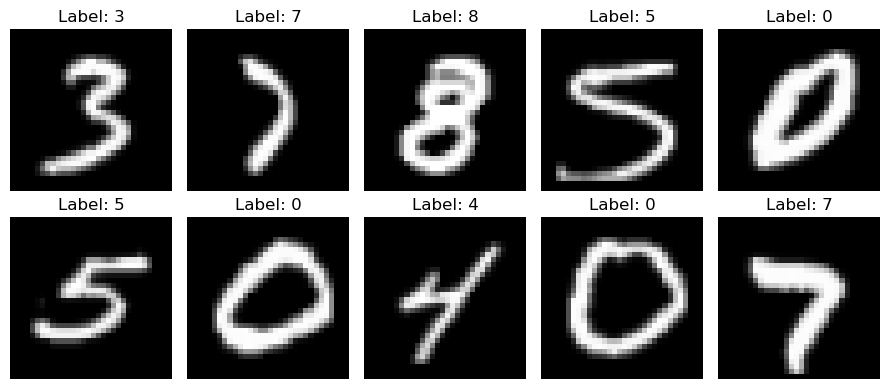

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i, 0].numpy() * 0.5 + 0.5, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Label: {labels[i].argmax().item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. 网络结构（独立代码单元格）

简化 LeNet 的形状变化：

| 层 | 单个样本的输出形状 |
|---|---|
| 输入 | 1×32×32 |
| 5×5 卷积，ReLU | 6×28×28 |
| 2×2 最大池化 | 6×14×14 |
| 5×5 卷积，ReLU | 16×10×10 |
| 2×2 平均池化 | 16×5×5 |
| 5×5 卷积，ReLU | 120×1×1 |
| 展平 | 120 |
| 全连接，ReLU | 84 |
| 全连接 | 10 |

卷积学习局部笔画，池化缩小特征图，全连接输出十类的 **logits**。交叉熵内部会处理 softmax，训练时不要额外添加 softmax。用 `nn.Sequential` 表示结构，也方便完整模型的保存和加载。

In [16]:
# 网络结构：本单元格仅定义 LeNet，不包含数据读取或训练循环。
model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(16, 120, kernel_size=5),
    nn.ReLU(),
    nn.Flatten(start_dim=1),
    nn.Linear(120, 84),
    nn.ReLU(),
    nn.Linear(84, 10),
)


## 5. 设备、损失函数与优化器

图像和模型统一为 float32；标签使用 float32 one-hot 编码，交叉熵直接接收类别概率目标。SGD 更新模型参数。

In [17]:
model = model.to(device=device, dtype=DTYPE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
print(model)
print("可训练参数:", sum(p.numel() for p in model.parameters() if p.requires_grad))
model.eval()
with torch.no_grad():
    sample_logits = model(images.to(device=device, dtype=DTYPE))
assert sample_logits.shape == (len(images), 10)
print("输出形状:", tuple(sample_logits.shape))


Sequential(
  (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (7): ReLU()
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=10, bias=True)
)
可训练参数: 61706
输出形状: (64, 10)


## 6. 训练与评估函数

训练使用 `model.train()`：清空梯度 → 前向传播 → 交叉熵 → 反向传播 → 更新参数。评估使用 `model.eval()` 和 `torch.no_grad()`，不更新参数。

每轮训练结束后，在同一组固定权重下重新遍历整个训练集和监控集，按样本数加权计算平均损失；不把训练期间参数不断变化的批量损失与监控损失比较。

In [18]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    for xb, yb in loader:
        xb = xb.to(device=device, dtype=DTYPE)
        yb = yb.to(device=device, dtype=DTYPE)
        if not torch.isfinite(xb).all():
            raise ValueError("输入图像包含 NaN/Inf")
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        if not torch.isfinite(loss):
            raise ValueError("训练损失出现 NaN/Inf")
        loss.backward()
        optimizer.step()


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device=device, dtype=DTYPE)
            yb = yb.to(device=device, dtype=DTYPE)
            logits = model(xb)
            loss = criterion(logits, yb)
            if not torch.isfinite(logits).all() or not torch.isfinite(loss):
                raise ValueError("评估输出或损失出现 NaN/Inf")
            total_loss += loss.item() * len(yb)
            correct += (logits.argmax(dim=1) == yb.argmax(dim=1)).sum().item()
            count += len(yb)
    return total_loss / count, correct / count


## 7. 固定轮数训练

监控损失只用于记录。这里不早停，不选最低监控损失的权重，最后一轮即为最终模型。重新训练时，应从上面的网络结构单元格开始重新运行，以重建模型和优化器。

In [19]:
train_loss_history, test_loss_history = [], []
train_accuracy_history, test_accuracy_history = [], []
for epoch in range(1, EPOCHS + 1):
    train_one_epoch(model, train_loader, criterion, optimizer)
    train_loss, train_accuracy = evaluate(model, train_eval_loader, criterion)
    monitor_loss, monitor_accuracy = evaluate(model, monitor_loader, criterion)
    train_loss_history.append(train_loss)
    test_loss_history.append(monitor_loss)
    train_accuracy_history.append(train_accuracy)
    test_accuracy_history.append(monitor_accuracy)
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss={train_loss:.4f}, accuracy={train_accuracy:.2%} | "
          f"monitor loss={monitor_loss:.4f}, accuracy={monitor_accuracy:.2%}")
model.eval()


Epoch 01/20 | train loss=0.1196, accuracy=96.26% | monitor loss=0.1256, accuracy=96.08%
Epoch 02/20 | train loss=0.0642, accuracy=97.99% | monitor loss=0.0730, accuracy=97.63%
Epoch 03/20 | train loss=0.0410, accuracy=98.76% | monitor loss=0.0530, accuracy=98.36%
Epoch 04/20 | train loss=0.0335, accuracy=99.00% | monitor loss=0.0497, accuracy=98.52%
Epoch 05/20 | train loss=0.0293, accuracy=99.10% | monitor loss=0.0474, accuracy=98.50%
Epoch 06/20 | train loss=0.0208, accuracy=99.36% | monitor loss=0.0470, accuracy=98.59%
Epoch 07/20 | train loss=0.0196, accuracy=99.40% | monitor loss=0.0465, accuracy=98.51%
Epoch 08/20 | train loss=0.0190, accuracy=99.41% | monitor loss=0.0481, accuracy=98.64%
Epoch 09/20 | train loss=0.0136, accuracy=99.58% | monitor loss=0.0387, accuracy=98.90%
Epoch 10/20 | train loss=0.0117, accuracy=99.66% | monitor loss=0.0430, accuracy=98.81%
Epoch 11/20 | train loss=0.0171, accuracy=99.44% | monitor loss=0.0492, accuracy=98.74%
Epoch 12/20 | train loss=0.0077,

Sequential(
  (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (7): ReLU()
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=10, bias=True)
)

## 8. 损失与准确率曲线（独立单元格）

蓝色实线表示训练集，红色虚线表示测试监控集。损失使用对数坐标；准确率表示正确分类的比例。两条曲线明显分离可能提示过拟合，但不能仅凭一次小样本实验作结论。

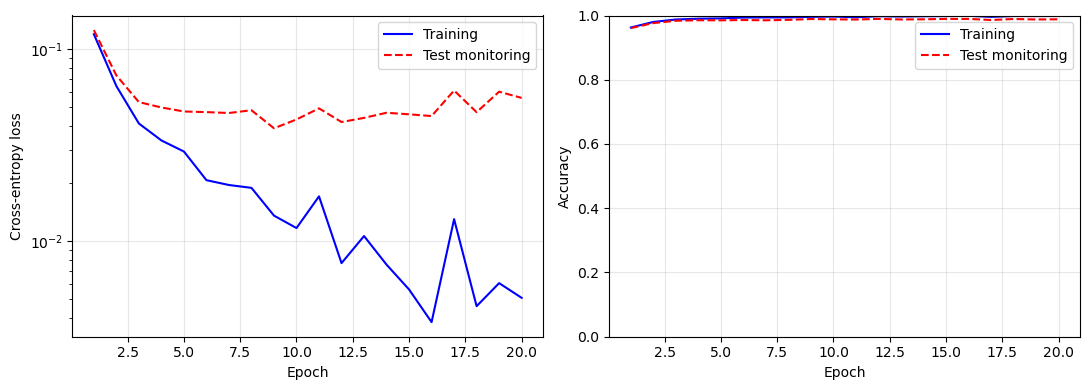

In [20]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, train_loss_history, color="blue", linestyle="-", label="Training")
axes[0].plot(epochs, test_loss_history, color="red", linestyle="--", label="Test monitoring")
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[1].plot(epochs, train_accuracy_history, color="blue", linestyle="-", label="Training")
axes[1].plot(epochs, test_accuracy_history, color="red", linestyle="--", label="Test monitoring")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


## 9. 官方测试集的最终评估

此集合未参与训练或逐轮监控。模型配置冻结后评估一次；如果根据这里的结果调整模型，它就不再是独立的最终测试集。

In [21]:
final_loss, final_accuracy = evaluate(model, final_loader, criterion)
print(f"官方测试样本数: {len(final_dataset)}")
print(f"Cross-entropy: {final_loss:.4f}")
print(f"Accuracy: {final_accuracy:.2%}")


官方测试样本数: 10000
Cross-entropy: 0.0426
Accuracy: 98.91%


## 10. 保存完整模型与预处理参数

保存最后一轮完整模型、固定预处理参数、配置和样本索引。预测时不用重建网络或重新训练。

In [22]:
model.eval()
# 深拷贝到 CPU 保存，避免改变当前模型所在设备。
import copy
saved_model = copy.deepcopy(model).cpu()
torch.save({
    "model": saved_model,
    "preprocess": preprocess_config,
    "dtype": "float32",
    "class_names": [str(i) for i in range(10)],
    "config": {"seed": SEED, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
               "learning_rate": LEARNING_RATE, "train_fraction": TRAIN_FRACTION},
    "train_indices": train_indices.tolist(),
    "monitor_indices": monitor_indices.tolist(),
    "final_indices": final_indices.tolist(),
    "history": {"train_loss": train_loss_history, "monitor_loss": test_loss_history,
                "train_accuracy": train_accuracy_history,
                "monitor_accuracy": test_accuracy_history},
}, MODEL_PATH)
print("保存至:", MODEL_PATH)


保存至: /Users/yemingxin/ROOT_Exercise/MachineLearning/CNN/HandWrite_model.pt


## 11. 独立加载与预测

以下代码不调用训练变量或训练函数，可在新内核中只运行此单元格及下方显示单元格。加载自己生成的可信模型；`weights_only=False` 允许完整对象反序列化，不用于来源不明的文件。图像必须复用保存的尺寸和归一化。

此处展示已完成最终评估的官方测试样本；softmax 最大值是模型给出的概率分数，不是经过校准的可靠性保证。自己拍摄的数字还需处理背景、裁剪、灰度极性和居中，不能直接假定与 MNIST 相同。

In [23]:
from pathlib import Path
import torch
from torchvision import datasets, transforms

# 独立预测同样强制使用 GPU，不依赖训练单元格中的设备变量。
if torch.cuda.is_available():
    prediction_device = torch.device("cuda")
elif torch.backends.mps.is_available():
    prediction_device = torch.device("mps")
else:
    raise RuntimeError("预测必须使用 GPU：未检测到可用的 CUDA 或 Apple MPS。")
checkpoint_path = Path.cwd() / "HandWrite_model.pt"
saved = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
loaded_model = saved["model"].to(device=prediction_device, dtype=torch.float32)
loaded_model.eval()
p = saved["preprocess"]
prediction_transform = transforms.Compose([
    transforms.Resize((p["image_size"],) * 2),
    transforms.ToTensor(),
    transforms.Normalize(p["mean"], p["std"]),
])
def encode_prediction_label(label):
    return torch.tensor([float(label == digit) for digit in range(10)], dtype=torch.float32)

prediction_dataset = datasets.MNIST(Path.cwd() / "data", train=False,
                                    download=True, transform=prediction_transform,
                                    target_transform=encode_prediction_label)
show_indices = saved["final_indices"][:10]
examples = [prediction_dataset[i] for i in show_indices]
prediction_images = torch.stack([image for image, label in examples])
true_targets = torch.stack([label for image, label in examples])
# argmax 返回类别索引，只用于显示/计数，不作为交叉熵的训练标签。
true_labels = true_targets.argmax(dim=1)
with torch.no_grad():
    logits = loaded_model(prediction_images.to(device=prediction_device, dtype=torch.float32))
    probabilities = torch.softmax(logits, dim=1).cpu()
    confidence, predictions = probabilities.max(dim=1)
for truth, pred, score in zip(true_labels.tolist(), predictions.tolist(), confidence.tolist()):
    print(f"真实数字: {truth}, 预测数字: {pred}, 概率分数: {score:.3f}")


真实数字: 6, 预测数字: 6, 概率分数: 1.000
真实数字: 6, 预测数字: 6, 概率分数: 1.000
真实数字: 0, 预测数字: 0, 概率分数: 1.000
真实数字: 9, 预测数字: 9, 概率分数: 1.000
真实数字: 4, 预测数字: 4, 概率分数: 1.000
真实数字: 8, 预测数字: 8, 概率分数: 1.000
真实数字: 9, 预测数字: 9, 概率分数: 1.000
真实数字: 1, 预测数字: 1, 概率分数: 1.000
真实数字: 7, 预测数字: 7, 概率分数: 1.000
真实数字: 7, 预测数字: 7, 概率分数: 1.000


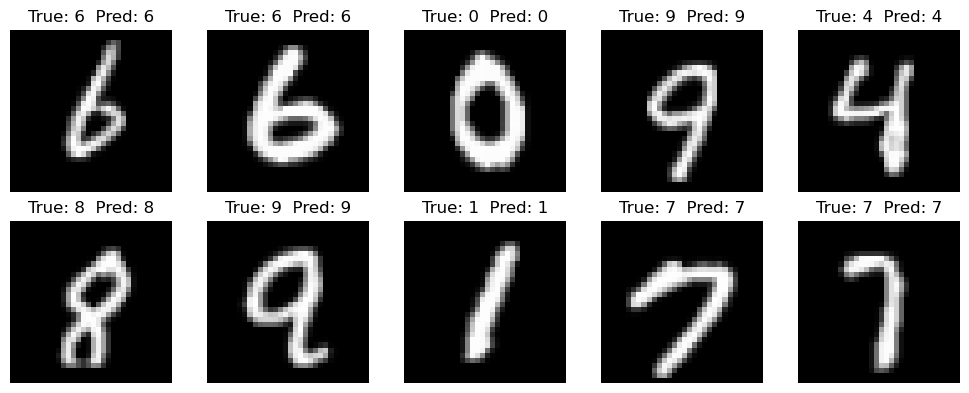

In [24]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    if i < len(prediction_images):
        image = prediction_images[i, 0].numpy() * p["std"][0] + p["mean"][0]
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        color = "black" if predictions[i] == true_labels[i] else "red"
        ax.set_title(f"True: {true_labels[i].item()}  Pred: {predictions[i].item()}", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()
